In [1]:
import pandas as pd
import spacy
import nltk
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 7.1 MB/s  0:00:01m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [3]:
nlp = spacy.load("en_core_web_sm")

In [4]:
df = pd.read_csv("climate-fever.csv")

In [5]:
df.head()

,claim_id,claim,claim_label,evidences/0/evidence_id,evidences/0/evidence_label,evidences/0/article,evidences/0/evidence,evidences/0/entropy,evidences/0/votes/0,evidences/0/votes/1,...,evidences/4/evidence_id,evidences/4/evidence_label,evidences/4/article,evidences/4/evidence,evidences/4/entropy,evidences/4/votes/0,evidences/4/votes/1,evidences/4/votes/2,evidences/4/votes/3,evidences/4/votes/4
0,0,Global warming is driving polar bears toward e...,SUPPORTS,Extinction risk from global warming:170,NOT_ENOUGH_INFO,Extinction risk from global warming,"""Recent Research Shows Human Activity Driving ...",0.693147,SUPPORTS,NOT_ENOUGH_INFO,...,Polar bear:1328,NOT_ENOUGH_INFO,Polar bear,"""Bear hunting caught in global warming debate"".",0.693147,SUPPORTS,NOT_ENOUGH_INFO,NaN,NaN,NaN
1,5,The sun has gone into ‘lockdown’ which could c...,SUPPORTS,Famine:386,SUPPORTS,Famine,The current consensus of the scientific commun...,0.000000,SUPPORTS,SUPPORTS,...,Winter:5,NOT_ENOUGH_INFO,Winter,"In many regions, winter is associated with sno...",0.693147,REFUTES,NOT_ENOUGH_INFO,NaN,NaN,NaN
2,6,The polar bear population has been growing.,REFUTES,Polar bear:1332,NOT_ENOUGH_INFO,Polar bear,"""Ask the experts: Are polar bear populations i...",0.693147,NOT_ENOUGH_INFO,REFUTES,...,Polar bear:61,REFUTES,Polar bear,Of the 19 recognized polar bear subpopulations...,0.000000,REFUTES,REFUTES,NaN,NaN,NaN
3,9,Ironic' study finds more CO2 has slightly cool...,REFUTES,Atmosphere of Mars:131,NOT_ENOUGH_INFO,Atmosphere of Mars,CO2 in the mesosphere acts as a cooling agent ...,0.693147,NOT_ENOUGH_INFO,SUPPORTS,...,Carbon dioxide:191,NOT_ENOUGH_INFO,Carbon dioxide,"Less energy reaches the upper atmosphere, whic...",0.000000,NOT_ENOUGH_INFO,NOT_ENOUGH_INFO,NaN,NaN,NaN
4,10,Human additions of CO2 are in the margin of er...,REFUTES,Carbon dioxide in Earth's atmosphere:140,NOT_ENOUGH_INFO,Carbon dioxide in Earth's atmosphere,While CO 2 absorption and release is always ha...,0.693147,NOT_ENOUGH_INFO,REFUTES,...,Sea:226,REFUTES,Sea,"More recently, anthropogenic activities have s...",0.000000,REFUTES,REFUTES,NaN,NaN,NaN


In [6]:
df.columns

Index(['claim_id', 'claim', 'claim_label', 'evidences/0/evidence_id',
       'evidences/0/evidence_label', 'evidences/0/article',
       'evidences/0/evidence', 'evidences/0/entropy', 'evidences/0/votes/0',
       'evidences/0/votes/1', 'evidences/0/votes/2', 'evidences/0/votes/3',
       'evidences/0/votes/4', 'evidences/1/evidence_id',
       'evidences/1/evidence_label', 'evidences/1/article',
       'evidences/1/evidence', 'evidences/1/entropy', 'evidences/1/votes/0',
       'evidences/1/votes/1', 'evidences/1/votes/2', 'evidences/1/votes/3',
       'evidences/1/votes/4', 'evidences/2/evidence_id',
       'evidences/2/evidence_label', 'evidences/2/article',
       'evidences/2/evidence', 'evidences/2/entropy', 'evidences/2/votes/0',
       'evidences/2/votes/1', 'evidences/2/votes/2', 'evidences/2/votes/3',
       'evidences/2/votes/4', 'evidences/3/evidence_id',
       'evidences/3/evidence_label', 'evidences/3/article',
       'evidences/3/evidence', 'evidences/3/entropy', 'evide

In [7]:
evidence_cols = [col for col in df.columns if col.endswith('evidence')]
print(evidence_cols)

['evidences/0/evidence', 'evidences/1/evidence', 'evidences/2/evidence', 'evidences/3/evidence', 'evidences/4/evidence']


In [8]:
df['combined_evidence'] = df[evidence_cols].apply(lambda row: " ".join(str(x) if isinstance(x, str) else "" for x in row), axis=1)
print(df[['combined_evidence']].head())

                                   combined_evidence
0  "Recent Research Shows Human Activity Driving ...
1  The current consensus of the scientific commun...
2  "Ask the experts: Are polar bear populations i...
3  CO2 in the mesosphere acts as a cooling agent ...
4  While CO 2 absorption and release is always ha...


In [9]:
def preprocess(text):
    return text.lower().strip()

In [10]:
df['processed_text'] = df['combined_evidence'].apply(preprocess)
df[['processed_text']].head()

,processed_text
0,"""recent research shows human activity driving ..."
1,the current consensus of the scientific commun...
2,"""ask the experts: are polar bear populations i..."
3,co2 in the mesosphere acts as a cooling agent ...
4,while co 2 absorption and release is always ha...


In [11]:
def extract_entities_pos(text):
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    pos_tags = [(token.text, token.pos_) for token in doc]
    return entities, pos_tags

In [12]:
for i, text in enumerate(df['processed_text'].head(5)):
    print(f"\n--- Article {i+1} ---")
    entities, pos_tags = extract_entities_pos(text)
    print("Entities:", entities)
    print("POS Tags:", pos_tags[:10])


--- Article 1 ---
Entities: [('arctic', 'LOC'), ('bee', 'ORG')]
POS Tags: [('"', 'PUNCT'), ('recent', 'ADJ'), ('research', 'NOUN'), ('shows', 'VERB'), ('human', 'ADJ'), ('activity', 'NOUN'), ('driving', 'VERB'), ('earth', 'NOUN'), ('towards', 'ADP'), ('global', 'ADJ')]

--- Article 2 ---
Entities: [('europe', 'LOC'), ('1315–1317', 'CARDINAL'), ('1348–1350', 'CARDINAL'), ('winter', 'DATE')]
POS Tags: [('the', 'DET'), ('current', 'ADJ'), ('consensus', 'NOUN'), ('of', 'ADP'), ('the', 'DET'), ('scientific', 'ADJ'), ('community', 'NOUN'), ('is', 'AUX'), ('that', 'SCONJ'), ('the', 'DET')]

--- Article 3 ---
Entities: [('eurasian', 'NORP'), ('arctic', 'LOC'), ('the 16th and 17th century', 'DATE'), ('the 1960s', 'DATE'), ('around 1968', 'DATE'), ('1,250', 'CARDINAL'), ('that year', 'DATE'), ('two', 'CARDINAL'), ('third', 'ORDINAL'), ('19', 'CARDINAL'), ('two', 'CARDINAL'), ('seven', 'CARDINAL'), ('nine', 'CARDINAL'), ('2017', 'DATE')]
POS Tags: [('"', 'PUNCT'), ('ask', 'VERB'), ('the', 'DET')

In [13]:
from collections import Counter

In [14]:
all_entities = []
for text in df['processed_text']:
    ents, _ = extract_entities_pos(text)
    all_entities.extend([label for _, label in ents])

In [15]:
entity_counts = Counter(all_entities)

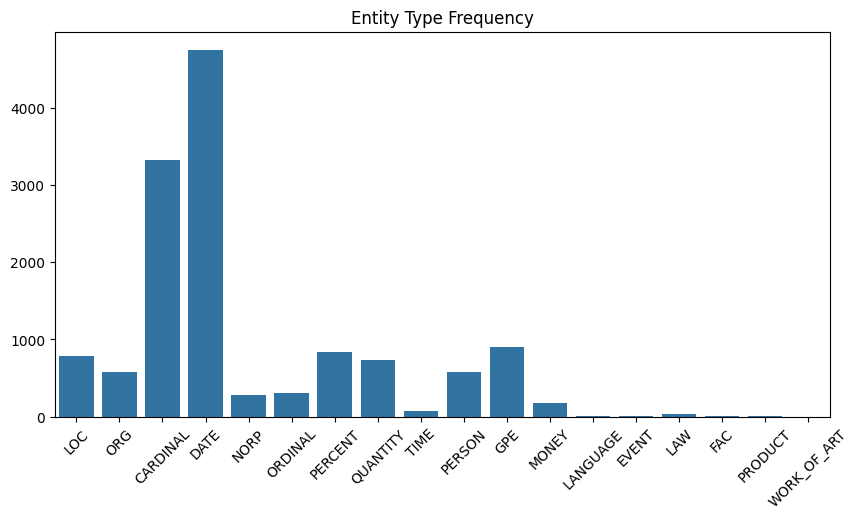

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(x=list(entity_counts.keys()), y=list(entity_counts.values()))
plt.xticks(rotation=45)
plt.title("Entity Type Frequency")
plt.show()

In [17]:
all_pos = []
for text in df['processed_text']:
    _, pos_tags = extract_entities_pos(text)
    all_pos.extend([pos for _, pos in pos_tags])

In [18]:
pos_counts = Counter(all_pos)

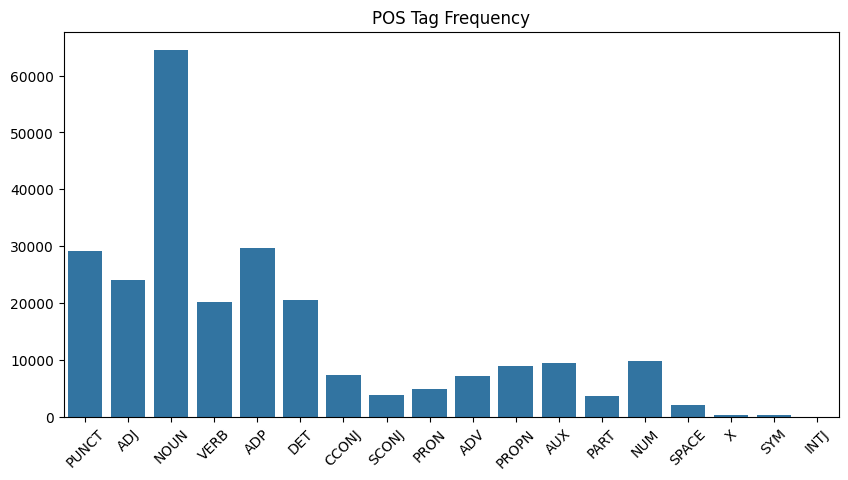

In [19]:
plt.figure(figsize=(10,5))
sns.barplot(x=list(pos_counts.keys()), y=list(pos_counts.values()))
plt.xticks(rotation=45)
plt.title("POS Tag Frequency")
plt.show()

# Observations

### NER:

- The most frequently detected entity types are CARDINAL, DATE, LOC (location), ORG (organization), and NORP (nationalities, religious or political groups).
- This aligns with expectations since climate-related articles often reference dates (e.g., years or periods), locations affected by climate change, and statistics or quantities.
- Some entity types, like PERSON, were rarely detected, which makes sense given that scientific discussions and reports focus more on data, regions, and events rather than individual people.

### POS:

- The most common parts of speech identified include NOUN, ADJ (adjective), VERB, and DET (determiners).
- The high frequency of nouns is consistent with the topic-focused nature of the dataset, which references key subjects such as "CO2", "climate", and "warming".
- Verbs like "shows", "driving", and "acts" highlight the explanatory and action-oriented sentences present in scientific texts.

### Dataset Characteristics:

- Several articles contain numeric data (like "2", "1315–1317") which spaCy classifies as CARDINAL. This suggests that numeric references are common in climate articles and may require specialized models for better understanding.
- Some terms, such as "CO2", are labeled as NOUN, possibly due to limitations in the model's vocabulary or its training data focus.

### Challenges Faced:

- The dataset contains noisy data and partially structured text, which affects entity recognition.
- Scientific terms and abbreviations are harder to classify using a general-purpose NLP model like en_core_web_sm.